In [61]:
import scipy.io
import networkx as nx 
import bct 
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import nilearn
from nilearn import datasets, plotting, surface

# Preparation of dataset for use
number_subjects = 9

# definition of directory with dataset
dir_fmri_desikan = '/strombolihome/fribeiro/Dataset/source_reconstructed_FC/fmri_connect_desikan/'
dir_fmri_destrieux = '/strombolihome/fribeiro/Dataset/source_reconstructed_FC/fmri_connect_destrieux/'

dir_eeg_desikan = '/strombolihome/fribeiro/Dataset/source_reconstructed_FC/eeg_connect_desikan/'
dir_eeg_destrieux = '/strombolihome/fribeiro/Dataset/source_reconstructed_FC/eeg_connect_destrieux/'

# importing labels of atlas
mat_desikan = scipy.io.loadmat('/strombolihome/fribeiro/Dataset/source_reconstructed_FC/label_dsk.mat', squeeze_me=True)
labels_desikan = mat_desikan['label_dsk']
labels_desikan[67] = 'rINS' # small correction

mat_destrieux = scipy.io.loadmat('/strombolihome/fribeiro/Dataset/source_reconstructed_FC/label_dstrx.mat', squeeze_me=True)
labels_destrieux = mat_destrieux['label_dstrx']
labels_destrieux = labels_destrieux[12:160]
labels_destrieux[147] = 'rS_temporal_transverse' # small correction


In [62]:
#1.Creation of average Graph 
def createAvGraph(file,data_type):
    
    # Load Matlab file with connectivity matrix for each time point - 3D matrix
    mat = scipy.io.loadmat(file)

    if data_type == 'fmri':
        conn_matrix = mat['connFMRI'].transpose() #connectivity fMRI matrix with numpy format
    elif data_type == 'eeg': #for now only for broad band TODO others !
        conn_matrix = mat['connEEGbroad'].transpose() #connectivity EEG matrix with numpy format
    elif data_type == 'eeg_alpha':
        conn_matrix = mat['connEEGalpha'].transpose()
    elif data_type == 'eeg_beta':
        conn_matrix = mat['connEEGbeta'].transpose()
    elif data_type == 'eeg_delta':
        conn_matrix = mat['connEEGdelta'].transpose()
    elif data_type == 'eeg_gamma':
        conn_matrix = mat['connEEGgamma'].transpose()
    elif data_type == 'eeg_theta':
        conn_matrix = mat['connEEGtheta'].transpose()
        
    t_points = conn_matrix.shape[0] # number of layers of multilayer matrix
    num_areas = conn_matrix.shape[1] #number of nodes of the graph
    
    # Get average connectivity matrix
    av_conn = np.zeros((num_areas,num_areas))
       
    for i in range(t_points):
        
        av_conn = av_conn + conn_matrix[i]
            
    av_conn = av_conn/t_points 
    
    G = nx.from_numpy_matrix(av_conn)
    
    return G

#2. Creation of array of graphs (equivalent to layers)
def createArrayGraph(file,data_type):
    
    # Load Matlab file with connectivity matrix for each time point - 3D matrix
    mat = scipy.io.loadmat(file)
    
    if data_type == 'fmri':
        conn_matrix = mat['connFMRI'].transpose() #connectivity fMRI matrix with numpy format
    elif data_type == 'eeg': #for now only for broad band TODO others !
        conn_matrix = mat['connEEGbroad'].transpose() #connectivity EEG matrix with numpy format
    elif data_type == 'eeg_alpha':
        conn_matrix = mat['connEEGalpha'].transpose()
    elif data_type == 'eeg_beta':
        conn_matrix = mat['connEEGbeta'].transpose()
    elif data_type == 'eeg_delta':
        conn_matrix = mat['connEEGdelta'].transpose()
    elif data_type == 'eeg_gamma':
        conn_matrix = mat['connEEGgamma'].transpose()
    elif data_type == 'eeg_theta':
        conn_matrix = mat['connEEGtheta'].transpose()

    t_points = conn_matrix.shape[0] # number of layers of multilayer matrix
    num_areas = conn_matrix.shape[1] #number of nodes of the graph
    
    array_graphs = np.empty(t_points, dtype=object) 
    
    for i in range(t_points):
        array_graphs[i] = nx.from_numpy_matrix(conn_matrix[i])
        
    return array_graphs

def thresholdGraph(G, threshold, type_data, type_threshold):
    
    if(type_data == 'fmri'):
        # get absolute value connectivity matrix
        conn_matrix = abs(nx.to_numpy_array(G))
    else:
        conn_matrix = nx.to_numpy_array(G)
     
    if (type_threshold == 'abs'):
        # to threshold graph keeping edges with weight equal or above certain value
        conn_new = bct.utils.threshold_absolute(conn_matrix, threshold, True)
    else:
        # to threshold graph keeping the top % of the edges 
        conn_new = bct.utils.threshold_proportional(conn_matrix, threshold, True)

    
    #for the fMRI data we need to recover non-absolute values as Phase Coherence is between -1 and 1
    if(type_data == 'fmri'):
        
        ind_keep = np.transpose(np.nonzero(conn_new))
        conn_new = np.zeros((G.number_of_nodes(), G.number_of_nodes()))
        min_positive = 1 #to store minimum positive value kept of phase coherence
        max_negative = -1 #to store maximum negative value kept of phase coherence
        
        idx_i, idx_j = zip(*ind_keep)

        conn_new[idx_i, idx_j] = nx.to_numpy_array(G)[idx_i, idx_j]
        
        #In case we want the minimum value of connectivity kept
        
        #for ind in ind_keep:
        #    #print(nx.to_numpy_array(G)[ind[0],ind[1]])
        #    conn_new[ind[0],ind[1]] = nx.to_numpy_array(G)[ind[0],ind[1]]
        #    #print(conn_new[ind[0],ind[1]])
        #    if nx.to_numpy_array(G)[ind[0],ind[1]] > 0 and nx.to_numpy_array(G)[ind[0],ind[1]] < min_positive:
        #        min_positive = nx.to_numpy_array(G)[ind[0],ind[1]]
        #    elif nx.to_numpy_array(G)[ind[0],ind[1]] < 0 and nx.to_numpy_array(G)[ind[0],ind[1]] > max_negative:
        #        max_negative = nx.to_numpy_array(G)[ind[0],ind[1]]
        
        G_new = nx.from_numpy_matrix(conn_new)
        
        return [G_new, conn_new, min_positive, max_negative]
    
    else:
        min_coh = np.amin(conn_new) #to store minimum value kept of imaginary part of coherency
        G_new = nx.from_numpy_matrix(conn_new)
        
        return [G_new, conn_new, min_coh] 

In [63]:
G_array_fmri = createArrayGraph(dir_fmri_desikan + 'subj01-7T/conn_desi_phase_coh_time_fmri.mat', 'fmri')
G_array_eeg = createArrayGraph(dir_eeg_desikan + 'subj01-7T/conn_desi_cohi_time_eeg_alpha_subj1-7T_.mat', 'eeg_alpha')

In [104]:
import seaborn as sns

def computeConnectivityStatistics(G_array, type_data, atlas, subject, threshold):
    
    if atlas == 'dsk':
        num_regions = 68
    else:
        num_regions = 148

    min_conn = np.zeros(len(G_array))
    max_conn = np.zeros(len(G_array))
    av_conn = np.zeros(len(G_array))
    std_conn = np.zeros(len(G_array))

    sparsity_conn = np.zeros(len(G_array))
    
    conn_matrix_max = np.zeros((num_regions, num_regions))
    conn_matrix_av = np.zeros((num_regions, num_regions))
    conn_matrix_all = []
    
    
    min_conn_threshold = np.zeros(len(G_array))
    max_conn_threshold = np.zeros(len(G_array))
    av_conn_threshold = np.zeros(len(G_array))
    std_conn_threshold = np.zeros(len(G_array))

    sparsity_conn_threshold = np.zeros(len(G_array))
    
    conn_matrix_max_threshold = np.zeros((num_regions, num_regions))
    conn_matrix_av_threshold = np.zeros((num_regions, num_regions))
    conn_matrix_all_threshold = []

    g = 0
    for G in G_array:
        
        if type_data == 'fmri':
            conn_matrix = abs(nx.to_numpy_matrix(G))
            G_new, conn_new, min_positive, max_negative = thresholdGraph(G, threshold, type_data, 'abs')
            conn_new = abs(conn_new)
        else:
            conn_matrix = nx.to_numpy_matrix(G)
            G_new, conn_new, min_coh = thresholdGraph(G, threshold, type_data, 'abs')
            
        np.fill_diagonal(conn_matrix, 0)

        conn_matrix_max = np.maximum(conn_matrix, conn_matrix_max)
        conn_matrix_max_threshold = np.maximum(conn_new, conn_matrix_max_threshold)
        
        conn_matrix_av += conn_matrix
        conn_matrix_av_threshold += conn_new
        
        if g == 0:
            conn_matrix_all = conn_matrix.flatten()
            conn_matrix_all_threshold = conn_new.flatten()
        else:
            vect_aux = conn_matrix.flatten()
            conn_matrix_all = np.concatenate([conn_matrix_all,vect_aux])
            vect_aux = conn_new.flatten()
            conn_matrix_all_threshold = np.concatenate([conn_matrix_all_threshold,vect_aux])

        min_conn[g] = np.min(conn_matrix)
        min_conn_threshold[g] = np.min(conn_new)
        max_conn[g] = np.max(conn_matrix)
        max_conn_threshold[g] = np.max(conn_new)
        av_conn[g] = conn_matrix.mean()
        av_conn_threshold[g] = conn_new.mean()
        std_conn[g] = np.std(conn_matrix)
        std_conn_threshold[g] = np.std(conn_new)
    
        #proportion of nonzeros in whole matrix
        sparsity_conn[g] = (num_regions*num_regions - np.count_nonzero(conn_matrix==0))/(num_regions*num_regions)
        sparsity_conn_threshold[g] = (num_regions*num_regions - np.count_nonzero(conn_new==0))/(num_regions*num_regions)
        
        g += 1

    conn_matrix_av = conn_matrix_av/len(G_array)
    conn_matrix_av_threshold = conn_matrix_av_threshold/len(G_array)
    
    # plot variation of minimum, maximum, average and standard deviation value over time - before and after threshold
    f = plt.figure(figsize=(40, 30))
    x_axis = np.arange(len(G_array))
    
    ax1 = plt.subplot(311)
    plt.plot(x_axis, min_conn, 'o-', color = 'blue')
    plt.plot(x_axis, max_conn, 'o-', color = 'red')
    plt.plot(x_axis, av_conn, 'o-', color = 'yellow')
    plt.plot(x_axis, std_conn, 'o-', color = 'green')
    plt.title('Evolution of max (in red), min (in blue), average (in yellow) and standard deviation (in green) - before threshold', fontsize=20)
    plt.setp(ax1.get_xticklabels(), fontsize=6)

    ax2 = plt.subplot(312, sharex=ax1, sharey=ax1)
    plt.plot(x_axis, min_conn_threshold, 'o-', color = 'blue')
    plt.plot(x_axis, max_conn_threshold, 'o-', color = 'red')
    plt.plot(x_axis, av_conn_threshold, 'o-', color = 'yellow')
    plt.plot(x_axis, std_conn_threshold, 'o-', color = 'green')
    plt.title('Evolution of max (in red), min (in blue), average (in yellow) and standard deviation (in green) - after threshold', fontsize=20)

    f.suptitle('Evolution over time of connectivity values before and after threshold', fontsize=30)
    plt.xlabel('time')
    plt.savefig('/strombolihome/fribeiro/Thesis_project/Results/connectivity_analysis/subj0' + str(subject) + '/plot_evolution_connectivity_metrics_over_time_' + type_data + '_threshold_' + str(threshold) + '_' + atlas + '.png')

    plt.show()
    
    fig1, ax1 = plt.subplots()
    # print average of minimum, maximum, average and standard deviation value over time - before and after threshold
    av_min = min_conn.mean()
    av_min_threshold = min_conn_threshold.mean()
    print("The average minimum value before thresholding is: " + str(av_min) + ' and after thresholding is: ' + str(av_min_threshold))
    av_max = max_conn.mean()
    av_max_threshold = max_conn_threshold.mean()
    print("The average maximum value before thresholding is: " + str(av_max) + 'and after thresholding is: ' + str(av_max_threshold))
    av = av_conn.mean()
    av_threshold = av_conn_threshold.mean()
    print("The average value before thresholding is: " + str(av) + ' and after thresholding is: ' + str(av_threshold))
    av_std = std_conn.mean()
    av_std_threshold = std_conn_threshold.mean()
    print("The average standard deviation value before thresholding is: " + str(av_std) + ' and after thresholding is: ' + str(av_std_threshold))
    data_before = np.concatenate((std_conn, av_conn, max_conn, min_conn))
    data_after = np.concatenate((std_conn_threshold, av_conn_threshold, max_conn_threshold, min_conn_threshold))
    data = [data_before, data_after]
    ax1.set_title('BoxPlot average connectivity metrics - before and after threshold')
    ax1.boxplot(data)
    plt.savefig('/strombolihome/fribeiro/Thesis_project/Results/connectivity_analysis/subj0' + str(subject) + '/box_plot_average_connectivity_metrics_' + type_data + '_threshold_' + str(threshold) + '_' + atlas + '.png')
    plt.show()
    
    # computation of sparsity over time and averaged - before and after threshold
    f = plt.figure(figsize=(20, 10))
    x_axis = np.arange(len(G_array))

    plt.plot(x_axis, sparsity_conn, 'o-', color = 'blue')
    plt.plot(x_axis, sparsity_conn_threshold, 'o-', color = 'green')
    f.suptitle('Evolution over time of sparsity - before (blue) and after (green) threshold', fontsize=20)
    plt.xlabel('time')
    plt.savefig('/strombolihome/fribeiro/Thesis_project/Results/connectivity_analysis/subj0' + str(subject) + '/sparsity_over_time_' + type_data + '_threshold_' + str(threshold) + '_' + atlas + '.png')
    plt.show()

    av_sparsity = sparsity_conn.mean()
    av_sparsity_threshold = sparsity_conn_threshold.mean()
    print("The average sparsity before thresholding is: " + str(av_sparsity) + ' and after thresholding is:' + str(av_sparsity_threshold))
    
    # plot distribution of connectivity values for each time point and for overall average - before and after threshold
    fig, axes = plt.subplots(1, 2, figsize=(20, 10), dpi=100)
    sns.distplot(conn_matrix_av, ax=axes[0],bins=50, rug=True, label="before")
    sns.distplot(conn_matrix_av_threshold,ax=axes[1], bins=50, rug=True, label="after")
    fig.suptitle('Distribution of connectivity values - averaging over time', fontsize=20)
    plt.savefig('/strombolihome/fribeiro/Thesis_project/Results/connectivity_analysis/subj0' + str(subject) + '/distribution_average_connectivity_values_' + type_data + '_threshold_' + str(threshold) + '_' + atlas + '.png')

    fig, axes = plt.subplots(1, 2, figsize=(20, 10), dpi=100)
    sns.distplot(conn_matrix_all, ax=axes[0], bins=50, rug=True, label="before")
    sns.distplot(conn_matrix_all_threshold, ax=axes[1],bins=50, rug=True, label="after")
    fig.suptitle('Distribution of connectivity values - all values over time', fontsize=20)
    plt.savefig('/strombolihome/fribeiro/Thesis_project/Results/connectivity_analysis/subj0' + str(subject) + '/distribution_all_connectivity_values_' + type_data + '_threshold_' + str(threshold) + '_' + atlas + '.png')

    fig, axes = plt.subplots(1, 2, figsize=(20, 10), dpi=100)
    sns.distplot(conn_matrix, ax=axes[0], bins=50, rug=True, label='before')
    sns.distplot(conn_new, ax=axes[1], bins=50, rug=True, label='after')
    fig.suptitle('Distribution of connectivity values', fontsize=20)
    plt.savefig('/strombolihome/fribeiro/Thesis_project/Results/connectivity_analysis/subj0' + str(subject) + '/distribution_connectivity_values_last_time_point_' + type_data + '_threshold_' + str(threshold) + '_' + atlas + '.png')
    
    f = plt.figure(figsize=(10, 10))
    plt.matshow(conn_matrix_av, fignum=f.number)
    plt.xticks(fontsize=14, rotation=45)
    plt.yticks(fontsize=14)
    cb = plt.colorbar()
    cb.ax.tick_params(labelsize=14)
    plt.title("Average connectivity matrix before threshold")
    plt.savefig('/strombolihome/fribeiro/Thesis_project/Results/connectivity_analysis/subj0' + str(subject) + '/coloured_matrix_average_connectivity_values_' + type_data + '_' + atlas + '.png')
    plt.show()
    
    f = plt.figure(figsize=(10, 10))
    plt.matshow(conn_matrix_av_threshold, fignum=f.number)
    plt.xticks(fontsize=14, rotation=45)
    plt.yticks(fontsize=14)
    cb = plt.colorbar()
    cb.ax.tick_params(labelsize=14)
    plt.title("Average connectivity matrix after threshold")
    plt.savefig('/strombolihome/fribeiro/Thesis_project/Results/connectivity_analysis/subj0' + str(subject) + '/coloured_matrix_average_connectivity_values_' + type_data + '_threshold_' + str(threshold) + '_' + atlas + '.png')
    plt.show()

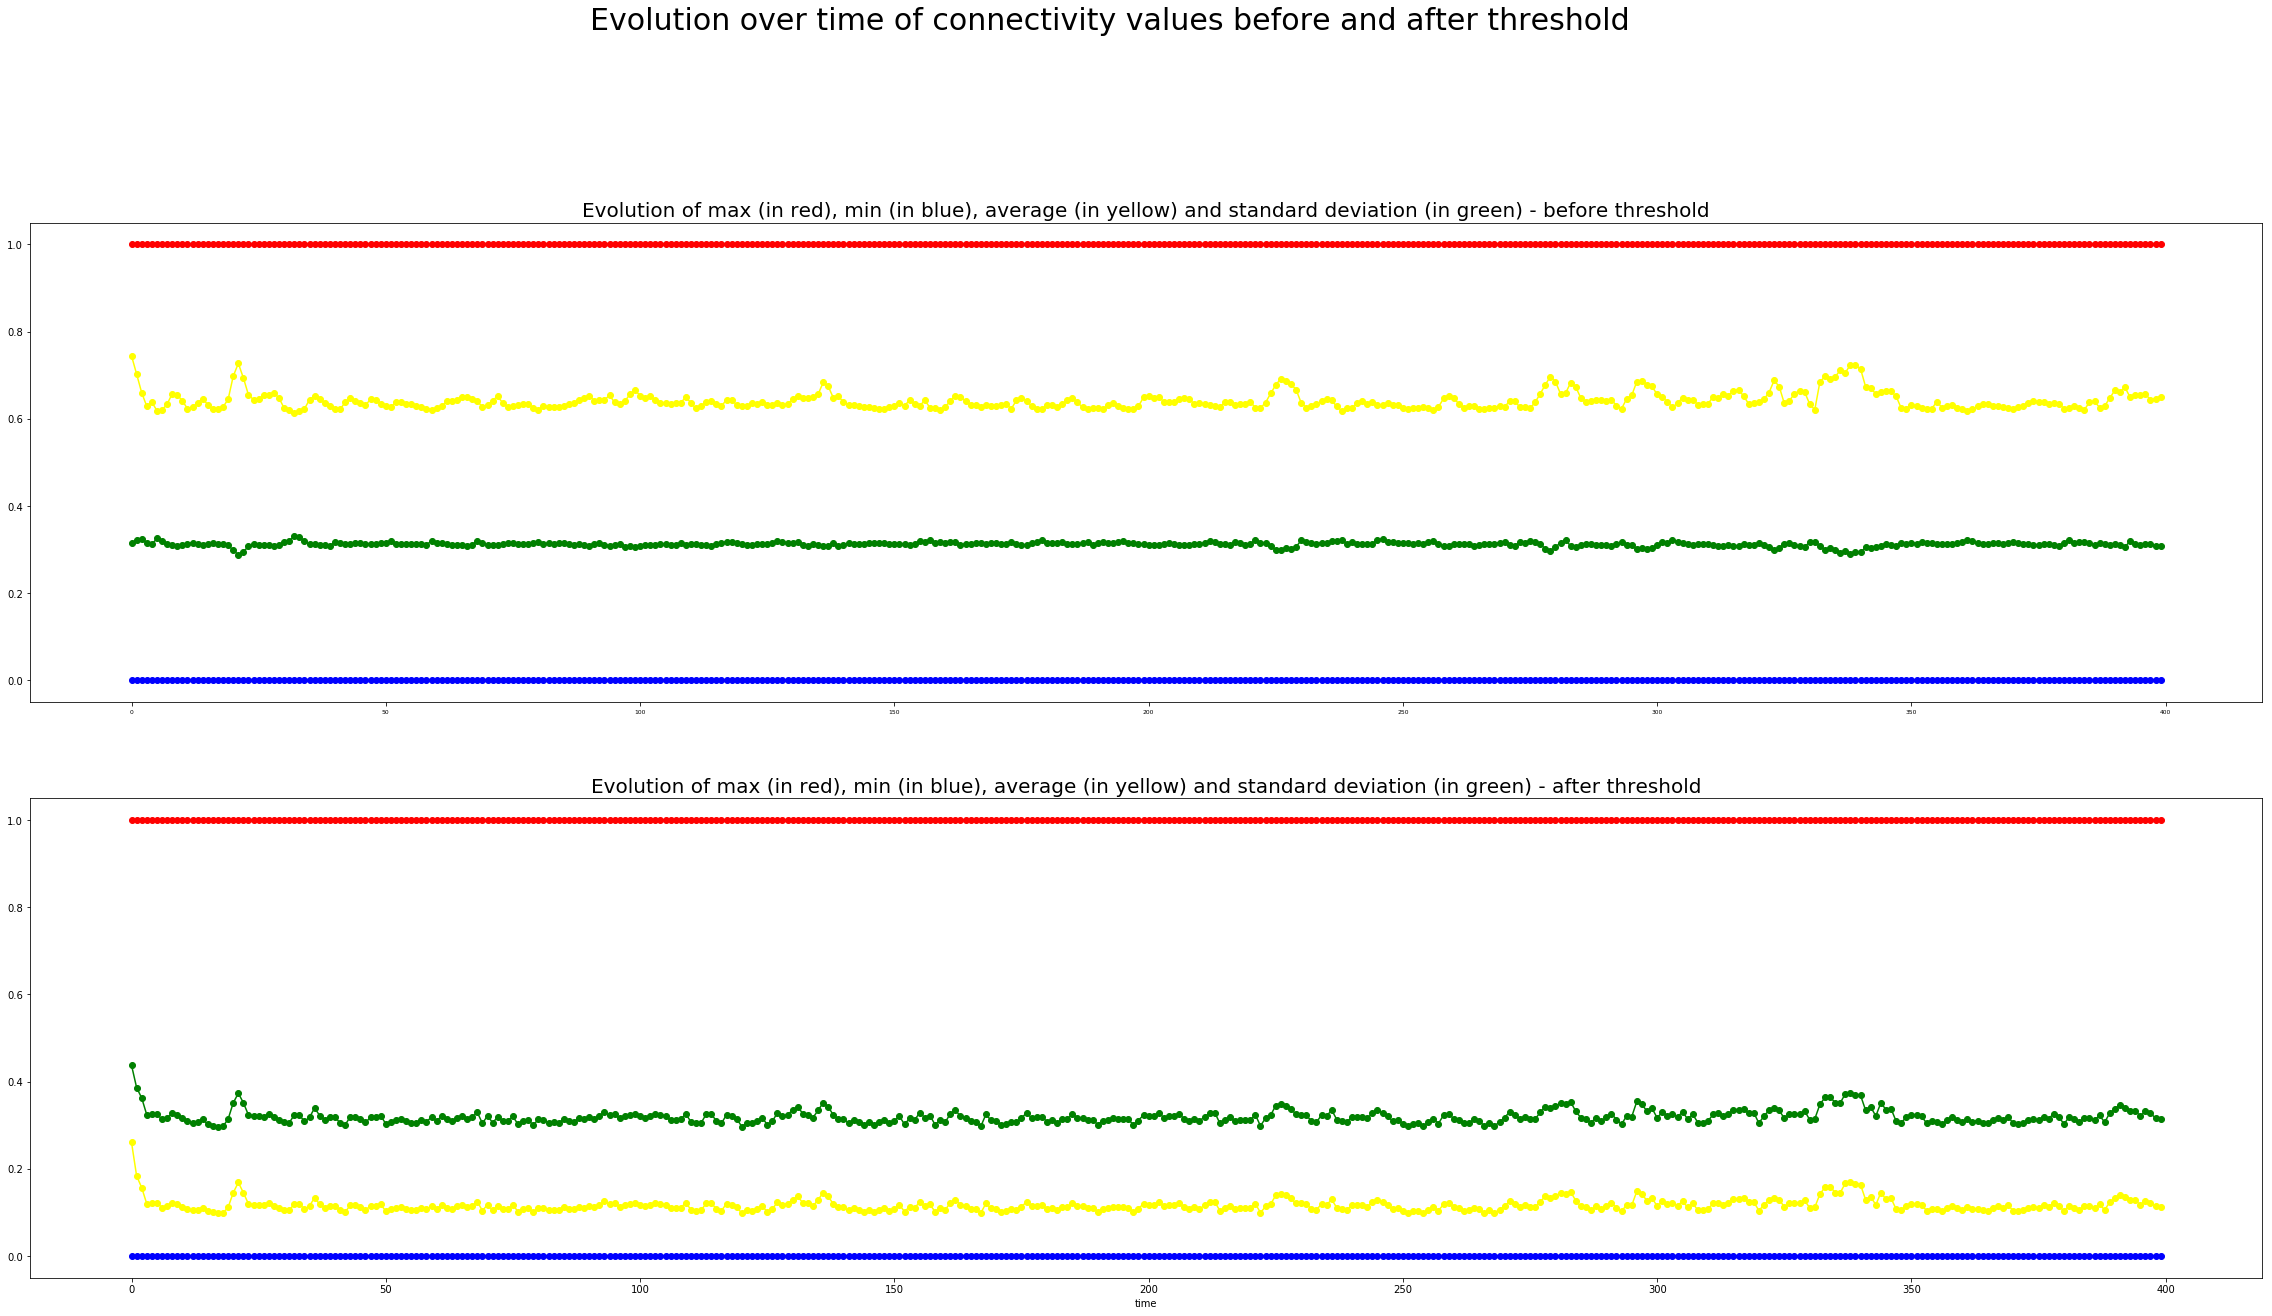

The average minimum value before thresholding is: 0.0 and after thresholding is: 0.0
The average maximum value before thresholding is: 0.999999615106and after thresholding is: 0.999999615106
The average value before thresholding is: 0.641297545576 and after thresholding is: 0.116437366452
The average standard deviation value before thresholding is: 0.312615713601 and after thresholding is: 0.319154103625


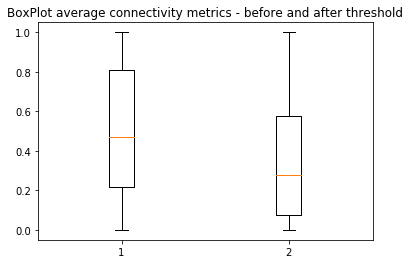

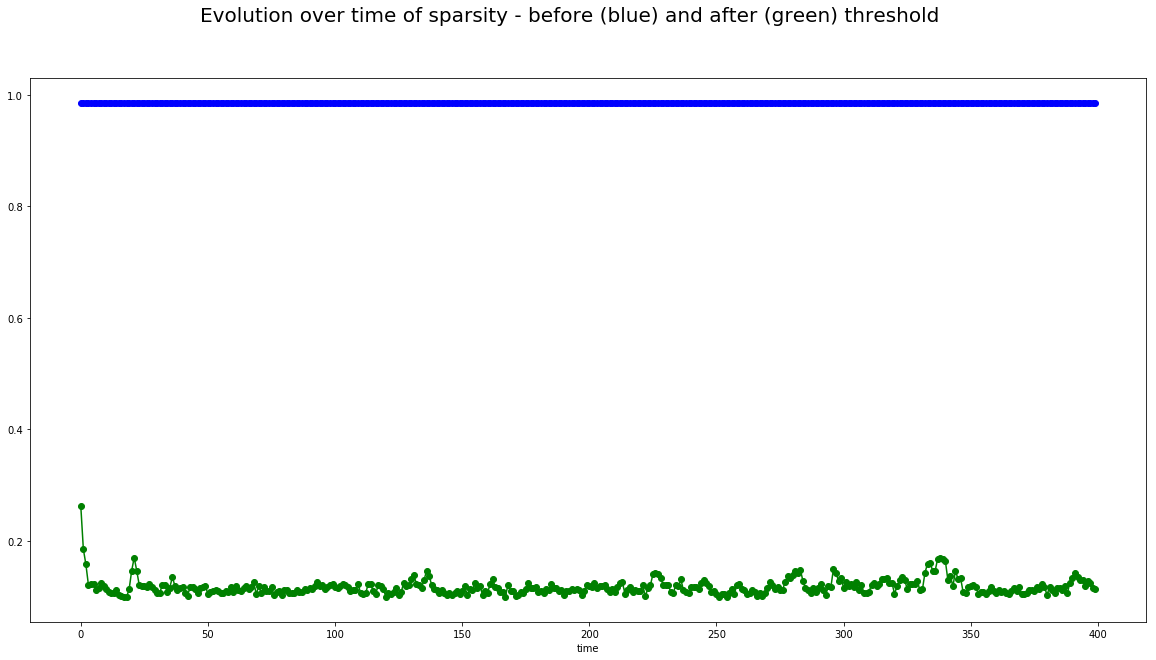

The average sparsity before thresholding is: 0.985294117647 and after thresholding is:0.117023140138


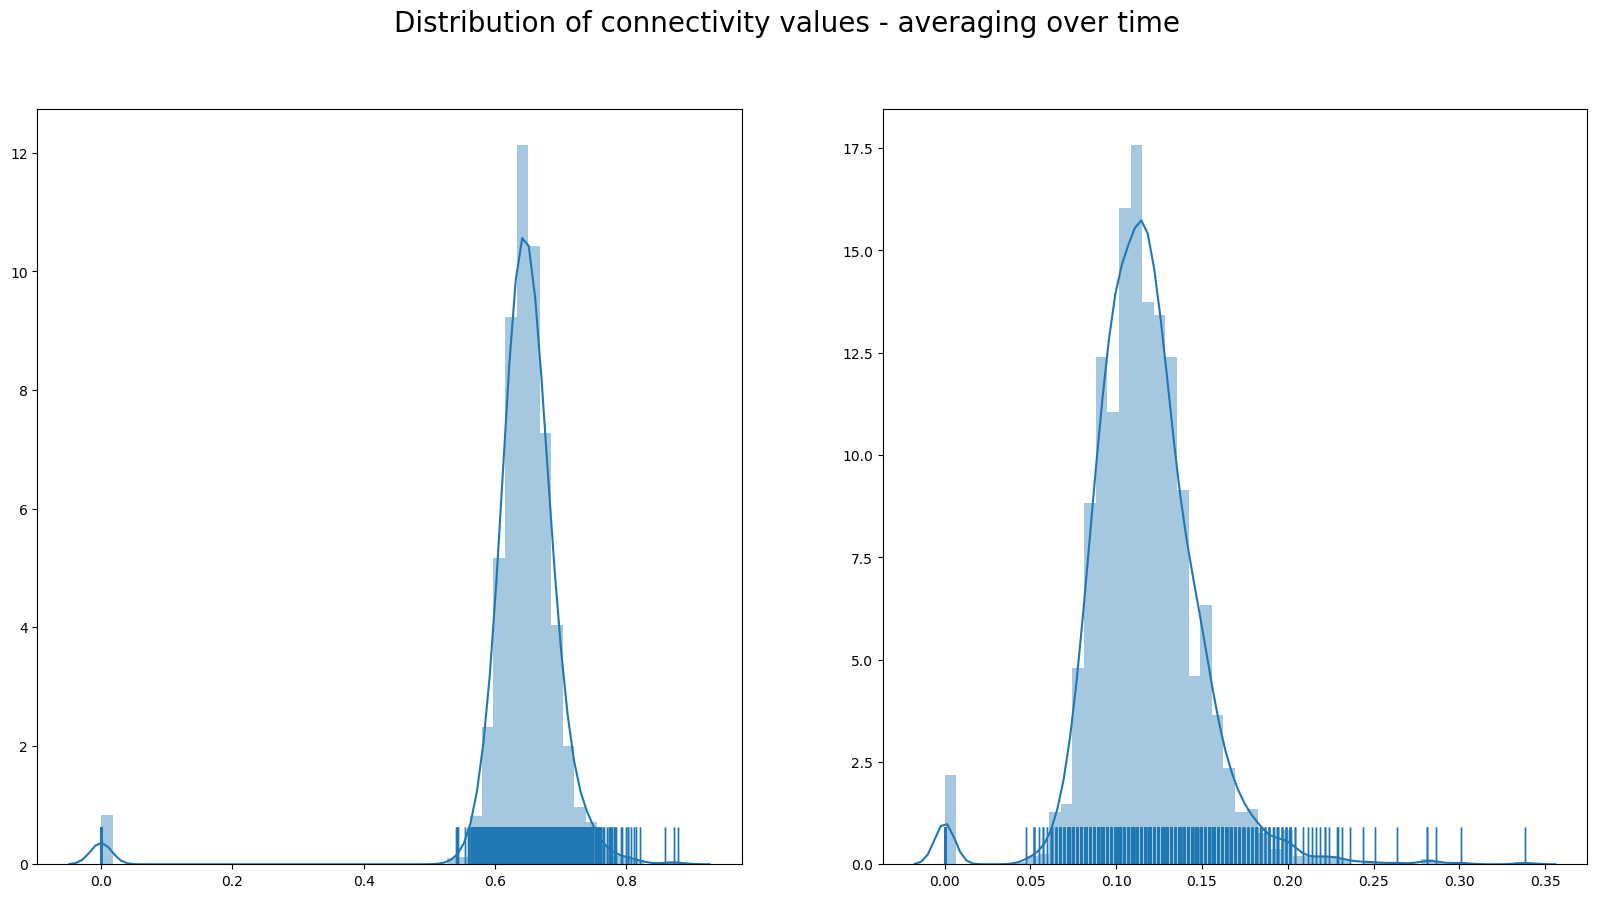

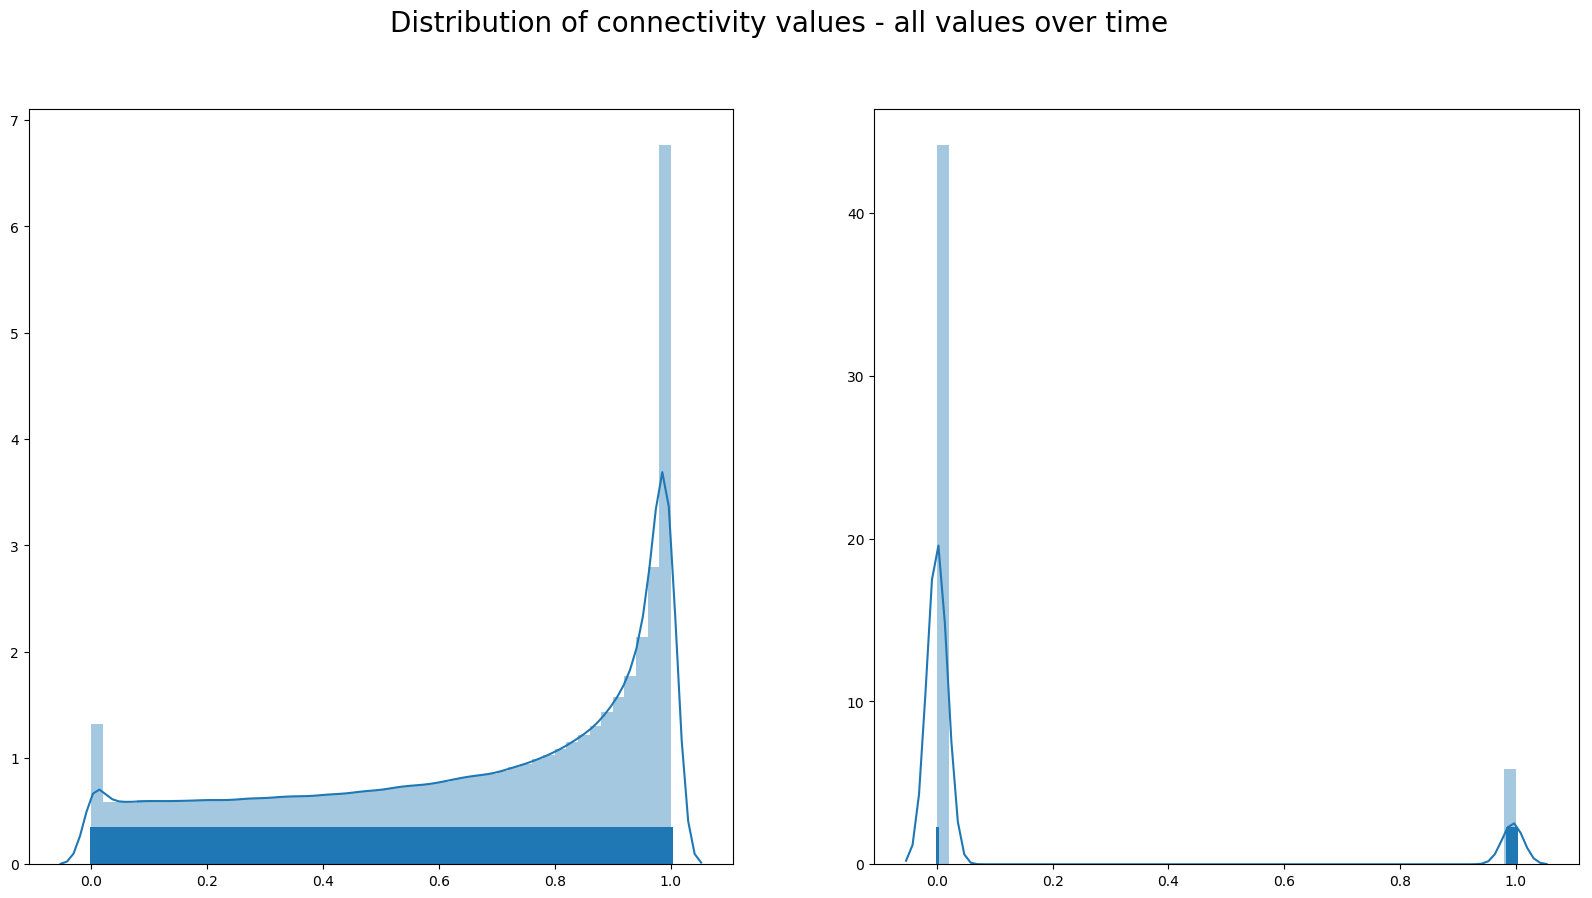

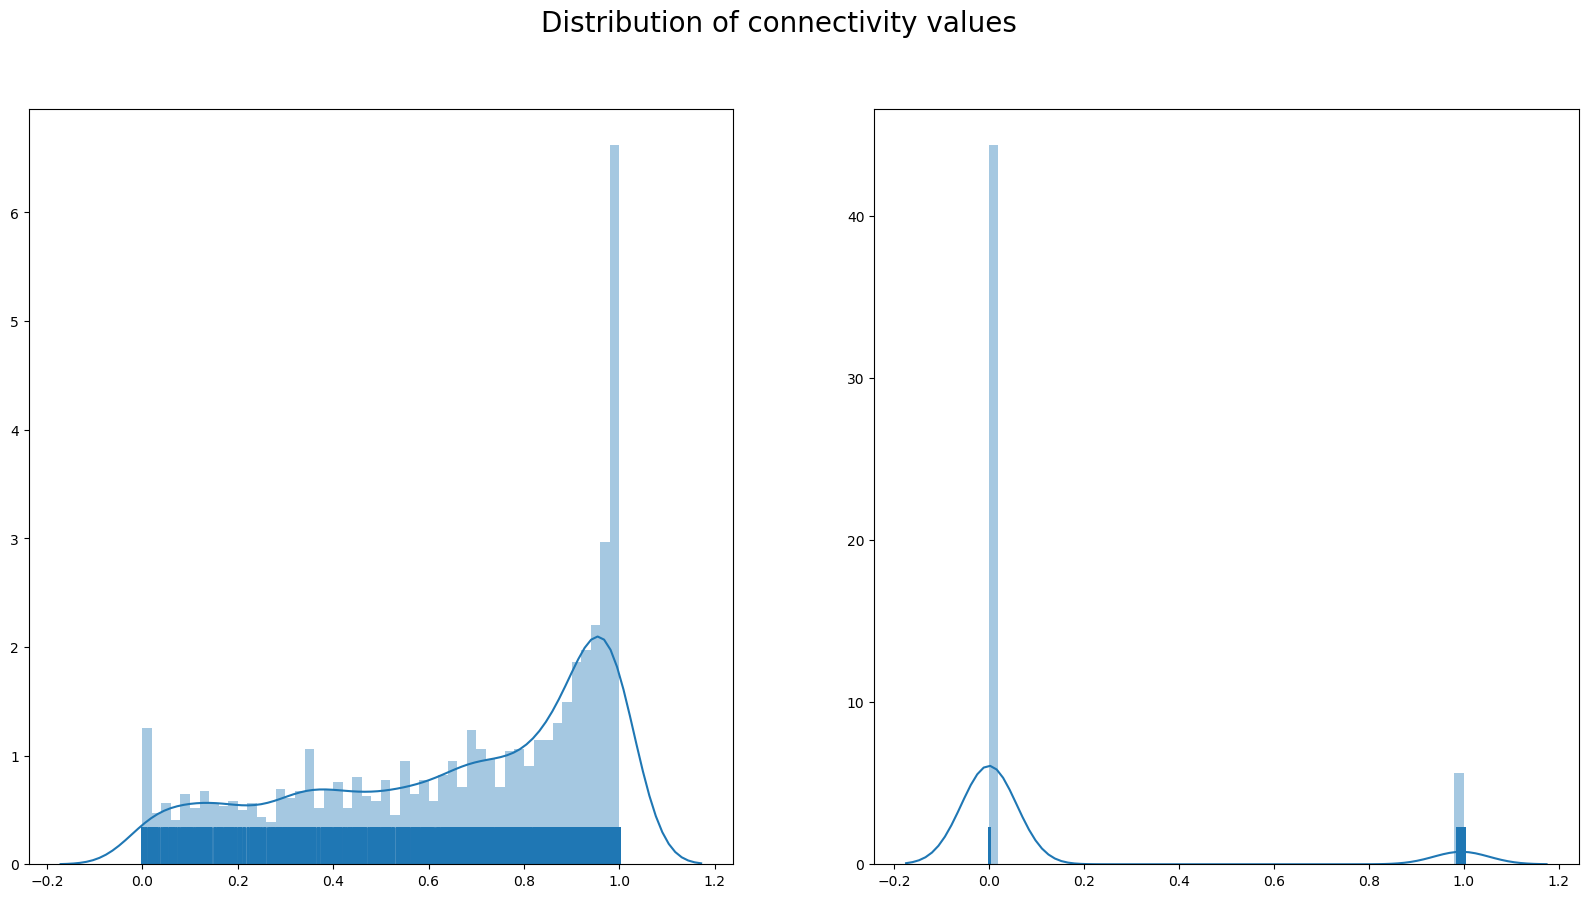

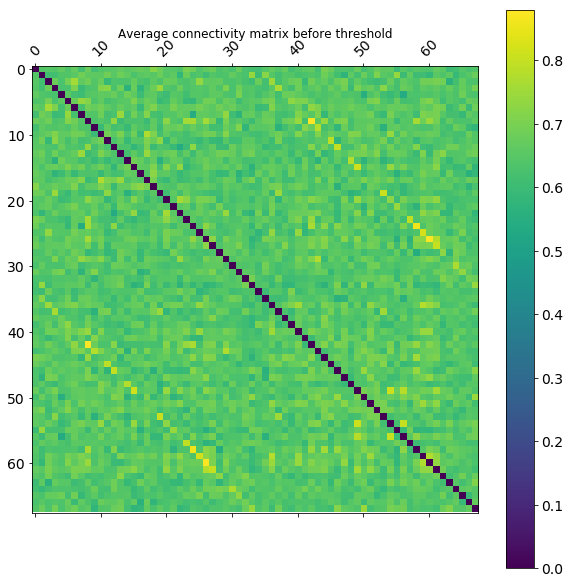

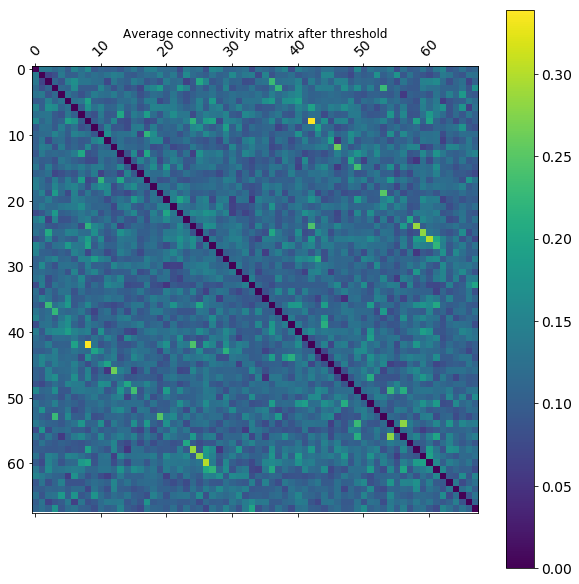

In [105]:
computeConnectivityStatistics(G_array_fmri, 'fmri', 'dsk', 1, 0.985)


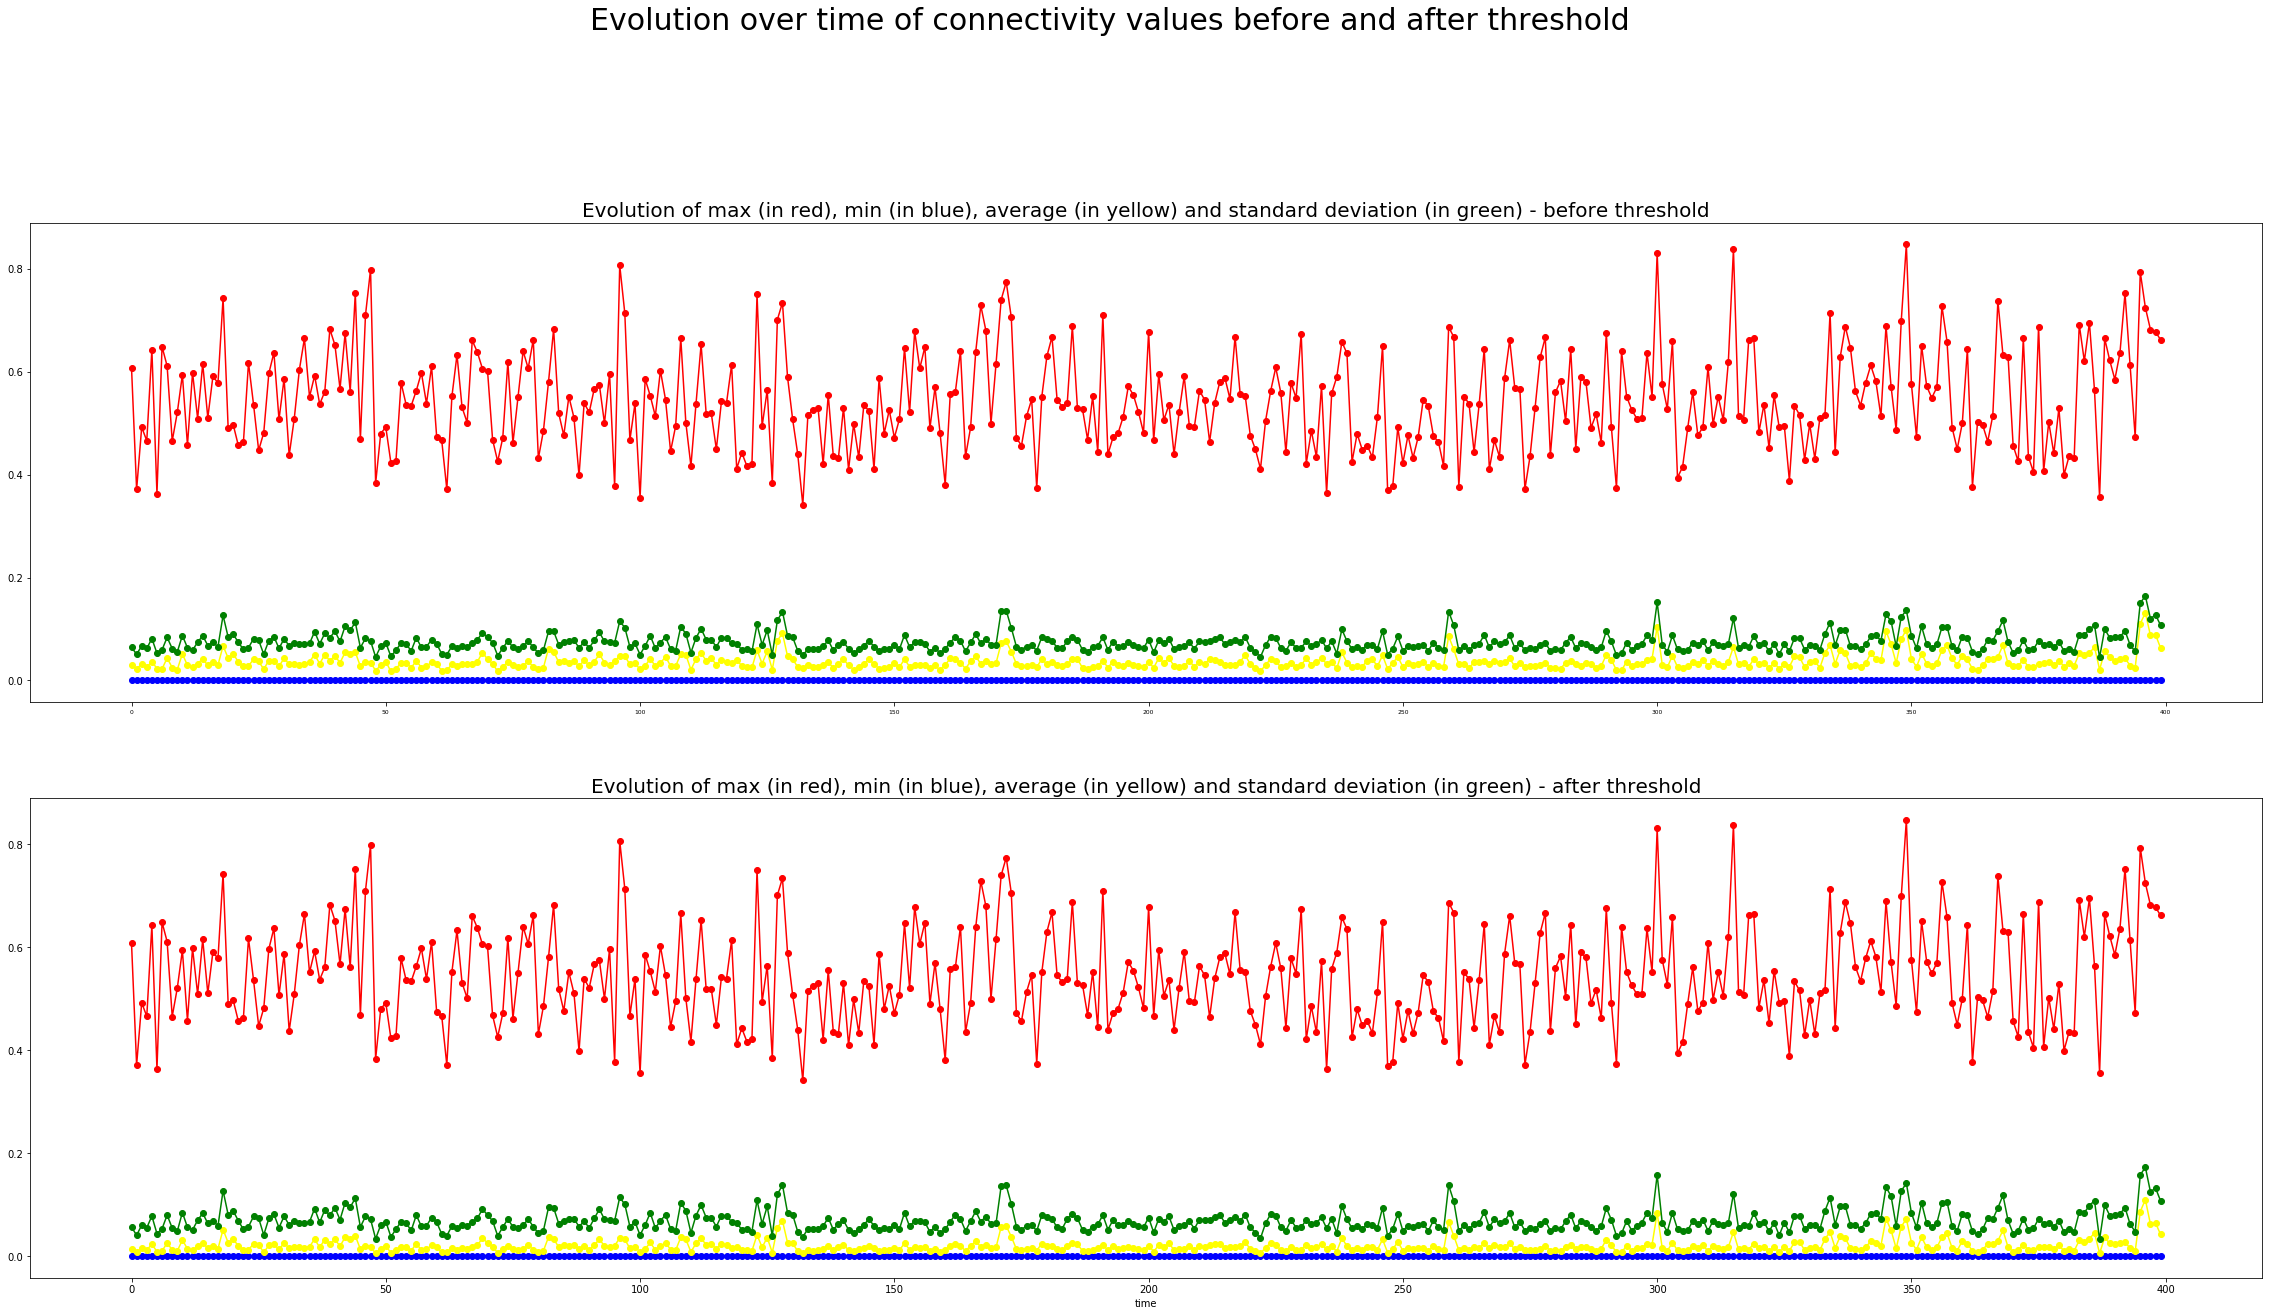

The average minimum value before thresholding is: 0.0 and after thresholding is: 0.0
The average maximum value before thresholding is: 0.542656761743and after thresholding is: 0.542656761743
The average value before thresholding is: 0.0364258534963 and after thresholding is: 0.0198462703004
The average standard deviation value before thresholding is: 0.0740778798273 and after thresholding is: 0.068309653967


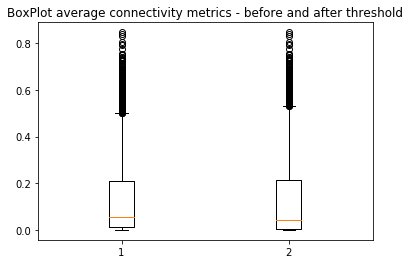

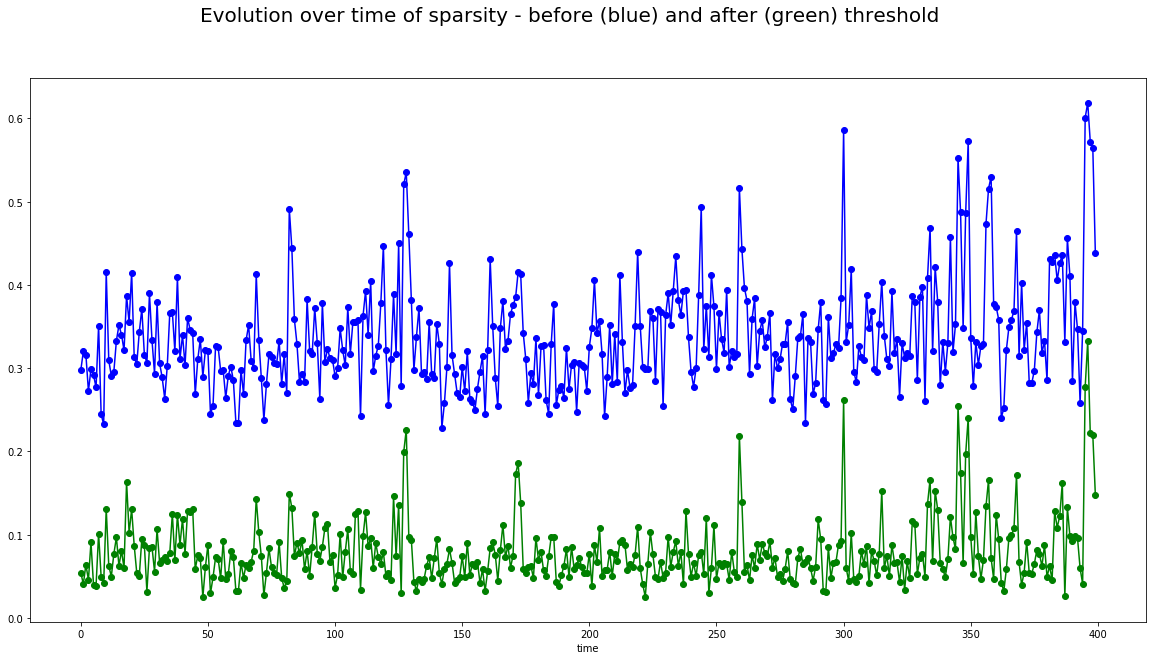

The average sparsity before thresholding is: 0.337488105536 and after thresholding is:0.0789803200692


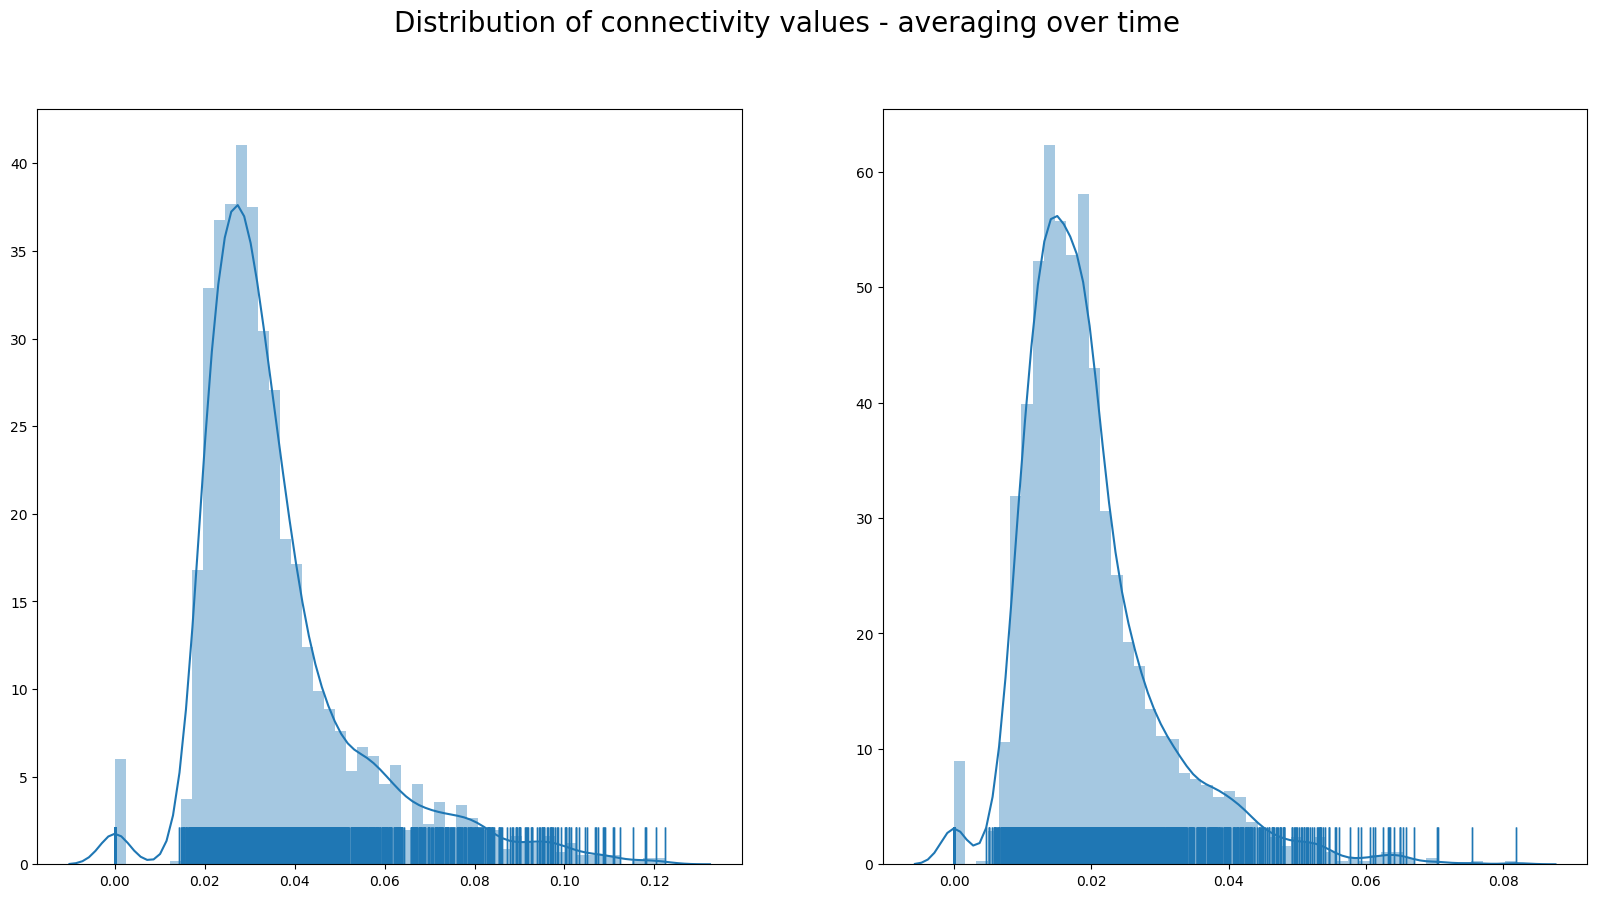

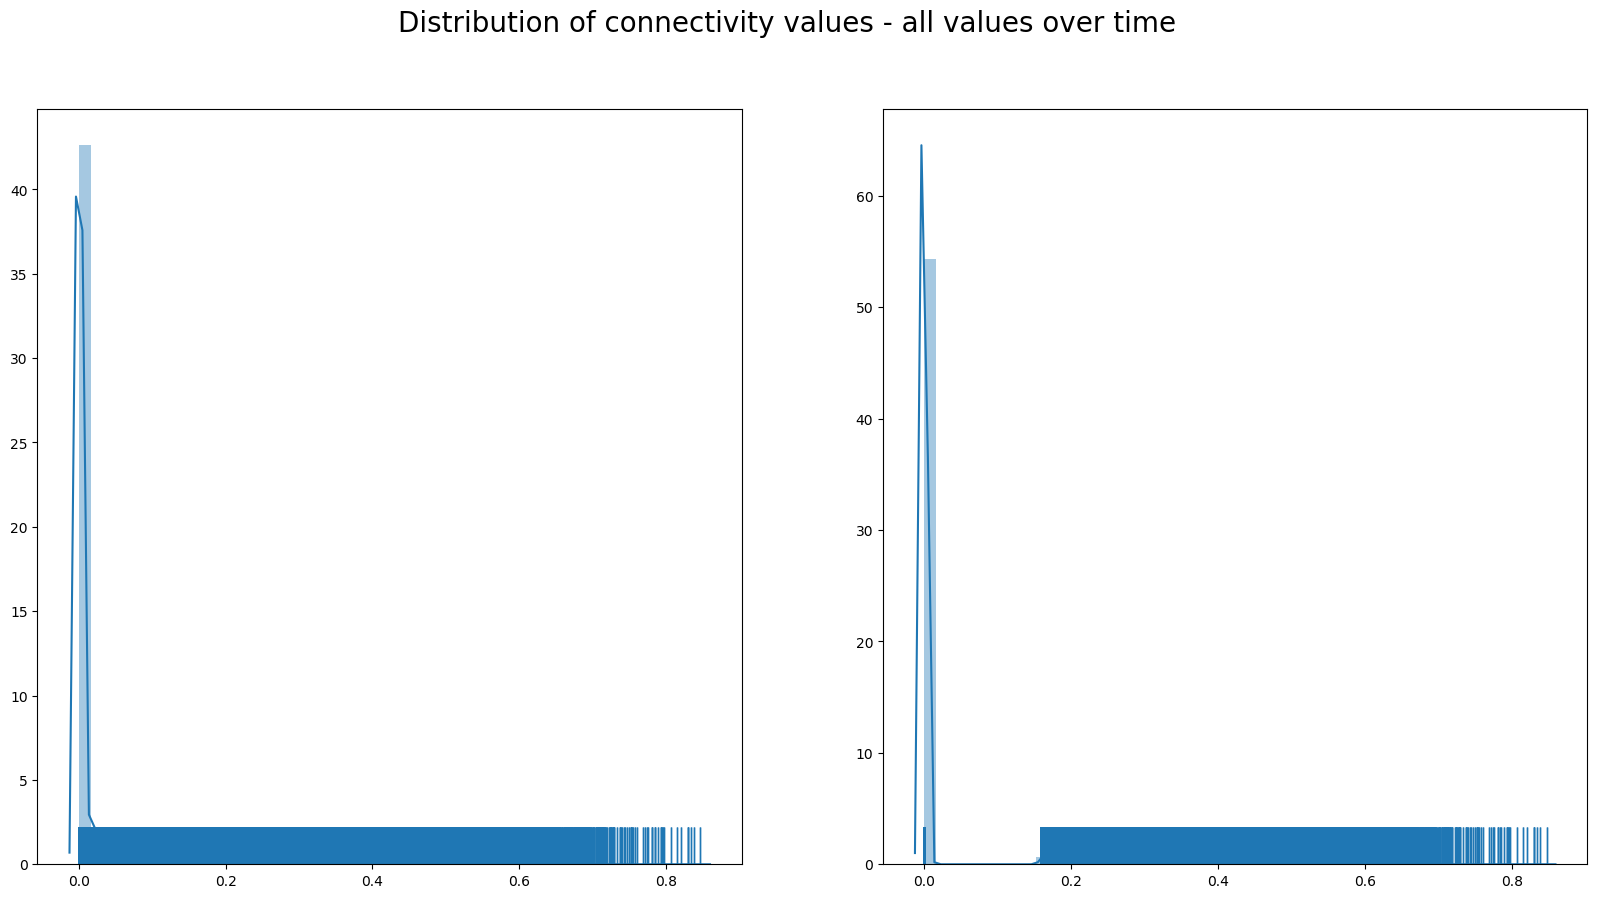

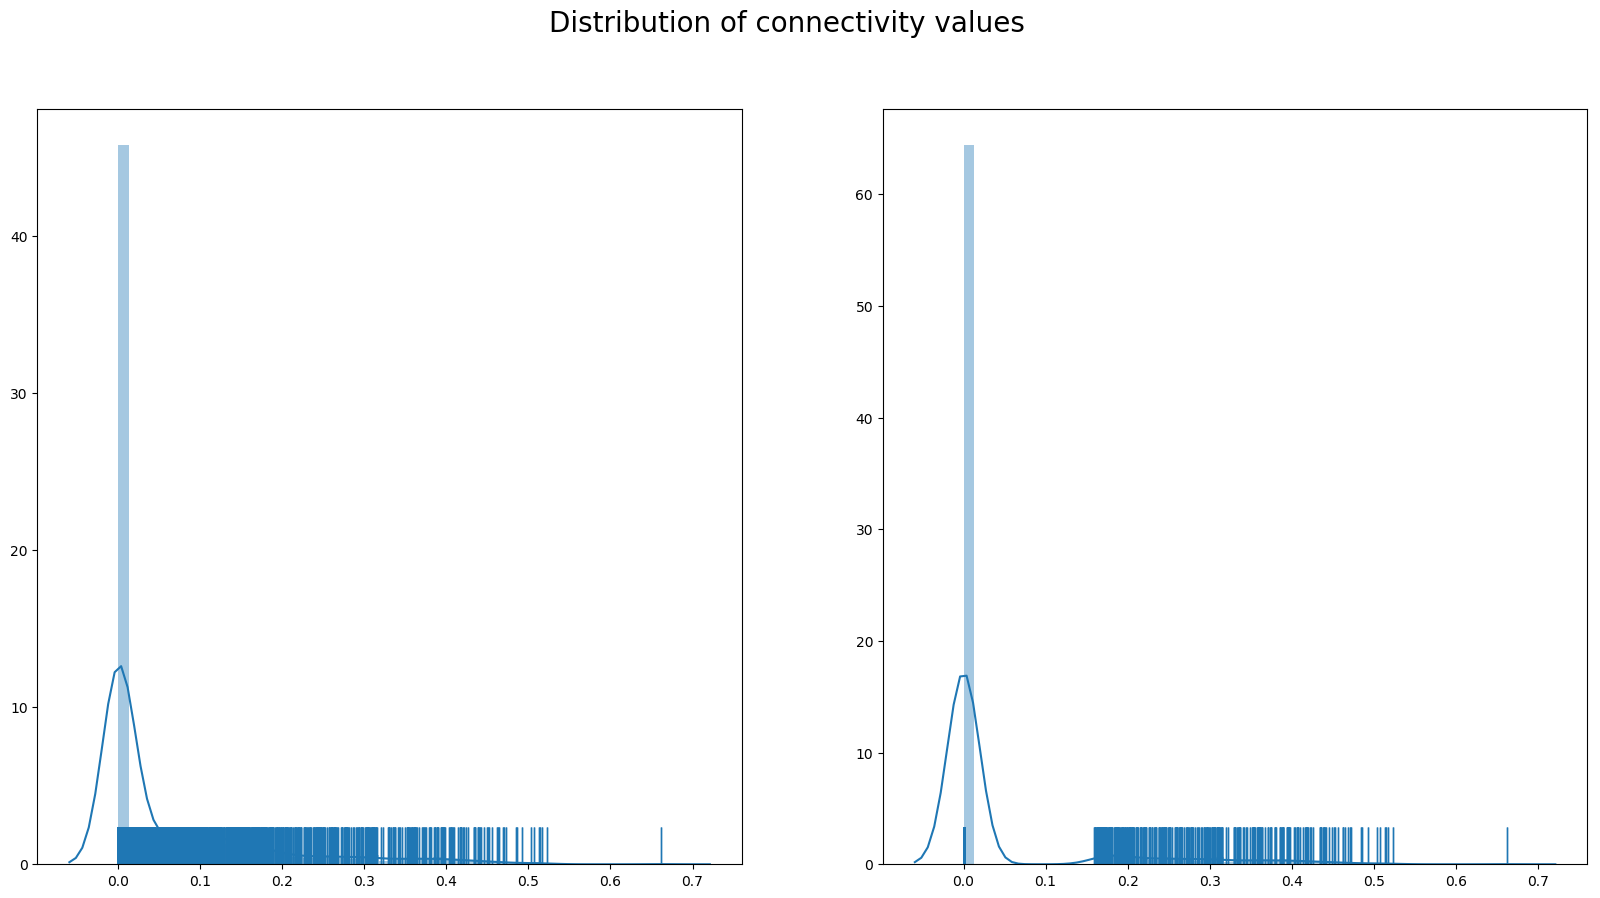

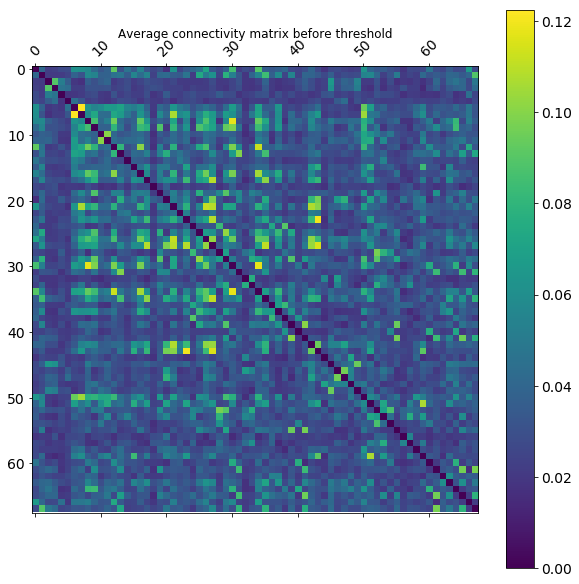

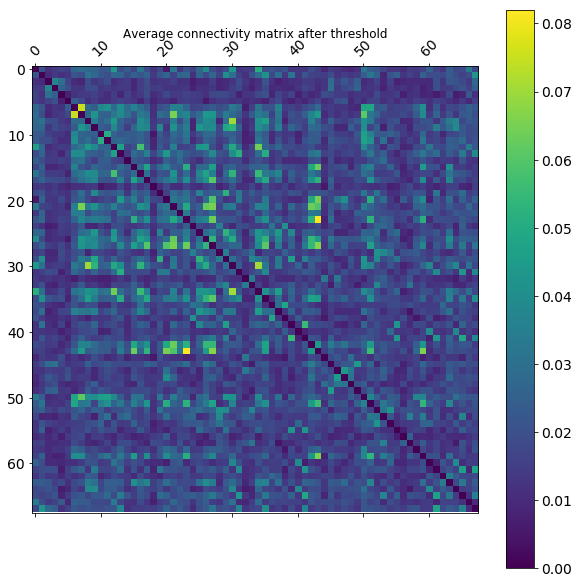

In [106]:
computeConnectivityStatistics(G_array_eeg, 'eeg_alpha', 'dsk', 1, 0.159)